<a href="https://colab.research.google.com/github/JanieliSilva/Redes_neurais/blob/main/Classifica%C3%A7%C3%A3o_flores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
lista = ['comprimento_sepala', 'largura_sepala', 'comprimento_petala', 'largura_petala', 'classe']
df.columns = lista

df.head(5)


,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,classe
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
classe = df [ 'classe'].unique()


In [5]:
entrada = df.iloc[:, 0:4].values
saida = df.iloc[:, 4].values


In [6]:
df.iloc[:, 4].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
dados_treino, dados_teste, saida_treino, saida_teste = train_test_split(entrada, saida, test_size=0.2)

In [8]:
sc = StandardScaler()
sc.fit(dados_treino)
dados_treino_padronizados = sc.transform(dados_treino)
dados_teste_pradronizado = sc.transform(dados_teste)
saida_treino_onehot = pd.get_dummies(saida_treino).values
saida_teste_onehot = pd.get_dummies(saida_teste).values

In [9]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(64, input_dim=4, activation='sigmoid', name='oculta'))
modelo.add(tf.keras.layers.Dense(3, activation='softmax', name='camada_saida'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta (Dense)                  │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_saida (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

In [11]:
history = modelo.fit(dados_treino, saida_treino_onehot, validation_split=0.2, epochs=100, batch_size=10)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4375 - loss: 1.1157 - val_accuracy: 0.6667 - val_loss: 0.9786
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.8764 - val_accuracy: 0.7500 - val_loss: 0.7629
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6979 - loss: 0.7177 - val_accuracy: 0.6667 - val_loss: 0.6216
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7708 - loss: 0.5855 - val_accuracy: 0.8750 - val_loss: 0.4924
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8542 - loss: 0.5075 - val_accuracy: 0.9167 - val_loss: 0.4203
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.4486 - val_accuracy: 1.0000 - val_loss: 0.3752
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.3924 - val_accuracy: 1.0000 - val_loss: 0.3307
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9479 - loss: 0.3627 - val_accuracy: 0.9583 - 

/tmp/ipykernel_2779/3219601374.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Treino', 'Teste', loc='upper left')


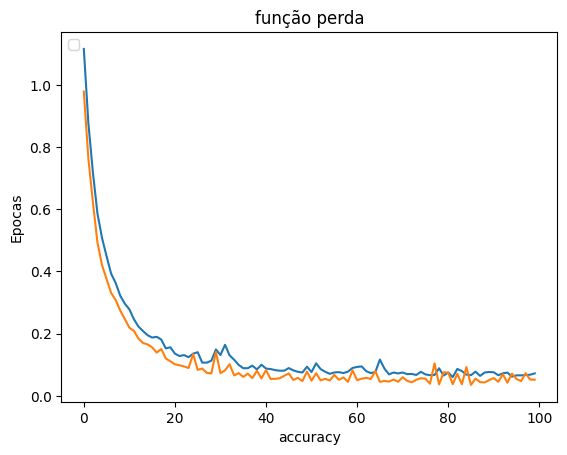

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('função perda')
plt.xlabel('accuracy')
plt.ylabel('Epocas')
plt.legend('Treino', 'Teste', loc='upper left')
plt.show()

In [13]:
teste = np.array([[5.1, 3.5, 1.4, 0.2]])
teste = sc.transform(teste)
y_predd = modelo.predict(teste)
y_predd =np.argmax(y_predd, axis=1)+1
print("A classe é:", y_predd[-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
A classe é: 1


In [26]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub
import os

In [27]:
path = kagglehub.dataset_download("gabrielluizone/high-school-alcoholism-and-academic-performance")

print("Path to dataset files:", path)

100%|██████████| 207k/207k [00:00<00:00, 60.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gabrielluizone/high-school-alcoholism-and-academic-performance/versions/7


In [28]:
arquivos = os.listdir(path)
print(arquivos)

['lpor_explorer.csv', 'documents', 'lpor_classification.csv', 'EN_Dataset', 'student-lpor.csv']


In [33]:
csv_path = os.path.join(path, 'student-lpor.csv')
df = pd.read_csv(csv_path, sep=';')
print(df.columns)
df.head()


Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2'], dtype='object')


,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [37]:
df = pd.read_csv(csv_path, sep=',', quotechar='"')

In [38]:
df.columns = [c.replace('"', '').strip() for c in df.columns]

In [39]:
print(f"Número de colunas encontradas: {len(df.columns)}")
df.head()

Número de colunas encontradas: 31


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,0,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,9,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,12,13
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,11,13


In [43]:
df['resultado'] = [1 if x >= 10 else 0 for x in df['G2']]

df[['G2', 'resultado']].head()

,G2,resultado
0,11,1
1,11,1
2,13,1
3,14,1
4,13,1


In [44]:
X = df.drop(['G1', 'G2', 'resultado'], axis=1)
X = pd.get_dummies(X)
y = df['resultado'].values

In [45]:
dados_treino, dados_teste, saida_treino, saida_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
sc = StandardScaler()
dados_treino_pad = sc.fit_transform(dados_treino)
dados_teste_pad = sc.transform(dados_teste)

In [59]:
print("Variáveis 'dados_treino_pad' e 'dados_teste_pad' criadas com sucesso!")

Variáveis 'dados_treino_pad' e 'dados_teste_pad' criadas com sucesso!


In [60]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [61]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(32, input_dim=X.shape[1], activation='relu'))
modelo.add(tf.keras.layers.Dropout(0.3))
modelo.add(tf.keras.layers.Dense(16, activation='relu'))
modelo.add(tf.keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

In [63]:
history = modelo.fit(dados_treino_pad, saida_treino,
                    validation_data=(dados_teste_pad, saida_teste),
                    epochs=100,
                    batch_size=16,
                    callbacks=[callback])

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5241 - loss: 0.7257 - val_accuracy: 0.7308 - val_loss: 0.5908
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7129 - loss: 0.5836 - val_accuracy: 0.8000 - val_loss: 0.5138
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7784 - loss: 0.5492 - val_accuracy: 0.8000 - val_loss: 0.4788
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7842 - loss: 0.5046 - val_accuracy: 0.7923 - val_loss: 0.4583
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7881 - loss: 0.4940 - val_accuracy: 0.7923 - val_loss: 0.4441
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7861 - loss: 0.4608 - val_accuracy: 0.7769 - val_loss: 0.4397
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7803 - loss: 0.4647 - val_accuracy: 0.7846 - val_loss: 0.4354
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8073 - loss: 0.4334 - val_accuracy: 0.7923 - v

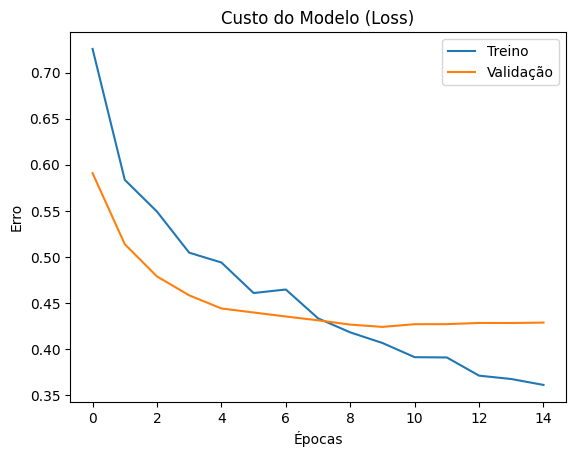

In [64]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Custo do Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.show()

In [65]:
print(f"Acurácia final no teste: {modelo.evaluate(dados_teste_padronizados,saida_teste)[1]:.2f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7846 - loss: 0.4241 
Acurácia final no teste: 0.78
